## Phase 1: Data Loading & Exploratory Data Analysis

In [ ]:
# Cell 1: Install dependencies
!pip install scikit-surprise --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("data/processed", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
# Cell 2: Download CiaoDVD dataset
!wget -q https://guoguibing.github.io/librec/datasets/CiaoDVD.zip -O CiaoDVD.zip
!unzip -o CiaoDVD.zip -d data/raw/
!rm CiaoDVD.zip
!ls data/raw/

Archive:  CiaoDVD.zip
  inflating: data/raw/movie-ratings.txt  
  inflating: data/raw/readme.txt     
  inflating: data/raw/review-ratings.txt  
  inflating: data/raw/trusts.txt     
movie-ratings.txt  readme.txt  review-ratings.txt  trusts.txt


In [4]:
# Cell 3: Load movie-ratings.txt
# Columns: userId, movieId, movie-categoryId, reviewId, movieRating, reviewDate
df = pd.read_csv(
    "data/raw/movie-ratings.txt",
    sep=",",
    header=None,
    names=["userId", "movieId", "categoryId", "reviewId", "rating", "date"]
)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (72665, 6)

First 5 rows:


,userId,movieId,categoryId,reviewId,rating,date
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


In [5]:
# Cell 4: Basic statistics
n_users = df["userId"].nunique()
n_movies = df["movieId"].nunique()
n_ratings = len(df)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print("=" * 45)
print(f"  Number of users       : {n_users:,}")
print(f"  Number of movies      : {n_movies:,}")
print(f"  Number of ratings     : {n_ratings:,}")
print(f"  Rating scale          : {df['rating'].min()} – {df['rating'].max()}")
print(f"  Matrix sparsity       : {sparsity:.4%}")
print(f"  Avg ratings/user      : {n_ratings/n_users:.2f}")
print(f"  Avg ratings/movie     : {n_ratings/n_movies:.2f}")
print("=" * 45)

  Number of users       : 17,615
  Number of movies      : 16,121
  Number of ratings     : 72,665
  Rating scale          : 1 – 5
  Matrix sparsity       : 99.9744%
  Avg ratings/user      : 4.13
  Avg ratings/movie     : 4.51


In [6]:
# Cell 5: Data quality check
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nRating value counts:\n{df['rating'].value_counts().sort_index()}")

# Drop duplicates if any
df = df.drop_duplicates()
print(f"\n Clean dataset shape: {df.shape}")

# Save cleaned version
df.to_csv("data/processed/ratings_clean.csv", index=False)
print(" Saved to data/processed/ratings_clean.csv")

Missing values:
 userId        0
movieId       0
categoryId    0
reviewId      0
rating        0
date          0
dtype: int64

Duplicate rows: 0

Rating value counts:
rating
1     2651
2     4685
3    10074
4    22560
5    32695
Name: count, dtype: int64

 Clean dataset shape: (72665, 6)
 Saved to data/processed/ratings_clean.csv


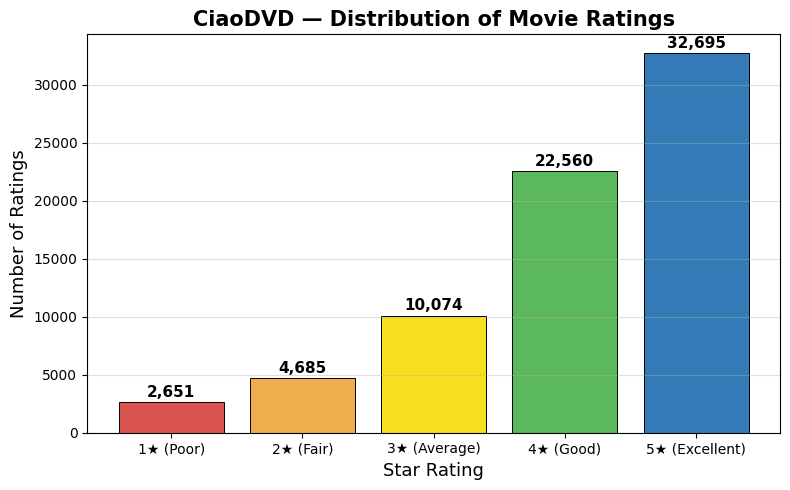

Saved rating_distribution.png


In [7]:
# Cell 6: Rating distribution histogram
fig, ax = plt.subplots(figsize=(8, 5))

rating_counts = df["rating"].value_counts().sort_index()
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=["#d9534f","#f0ad4e","#f7df1e","#5cb85c","#337ab7"],
              edgecolor="black", linewidth=0.7)

# Add count labels on top of bars
for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{count:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xlabel("Star Rating", fontsize=13)
ax.set_ylabel("Number of Ratings", fontsize=13)
ax.set_title("CiaoDVD — Distribution of Movie Ratings", fontsize=15, fontweight="bold")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["1★ (Poor)", "2★ (Fair)", "3★ (Average)", "4★ (Good)", "5★ (Excellent)"])
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("results/figures/rating_distribution.png", dpi=150)
plt.show()
print("Saved rating_distribution.png")

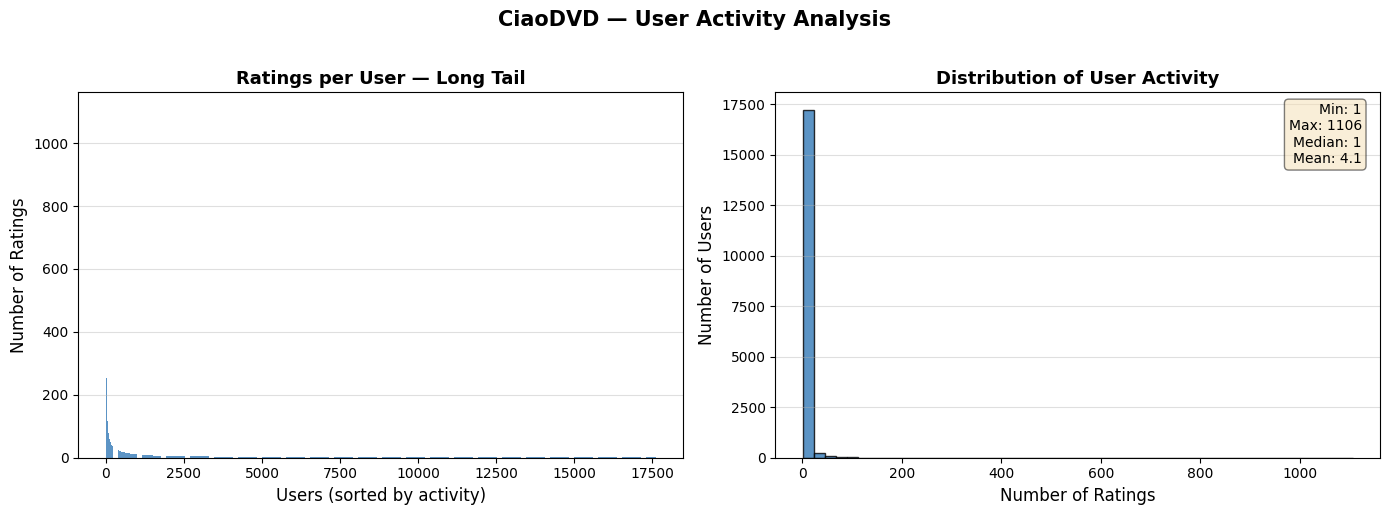

Saved ratings_per_user.png


In [8]:
# Cell 7: Ratings per user — long tail distribution
ratings_per_user = df.groupby("userId")["rating"].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sorted bar (long tail)
axes[0].bar(range(len(ratings_per_user)), ratings_per_user.values,
            color="#337ab7", alpha=0.8)
axes[0].set_xlabel("Users (sorted by activity)", fontsize=12)
axes[0].set_ylabel("Number of Ratings", fontsize=12)
axes[0].set_title("Ratings per User — Long Tail", fontsize=13, fontweight="bold")
axes[0].grid(axis="y", alpha=0.4)

# Right: histogram
axes[1].hist(ratings_per_user.values, bins=50, color="#337ab7",
             edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Number of Ratings", fontsize=12)
axes[1].set_ylabel("Number of Users", fontsize=12)
axes[1].set_title("Distribution of User Activity", fontsize=13, fontweight="bold")
axes[1].grid(axis="y", alpha=0.4)

# Stats annotation
stats_text = (f"Min: {ratings_per_user.min()}\n"
              f"Max: {ratings_per_user.max()}\n"
              f"Median: {ratings_per_user.median():.0f}\n"
              f"Mean: {ratings_per_user.mean():.1f}")
axes[1].text(0.97, 0.97, stats_text, transform=axes[1].transAxes,
             va="top", ha="right", fontsize=10,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("CiaoDVD — User Activity Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/figures/ratings_per_user.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ratings_per_user.png")

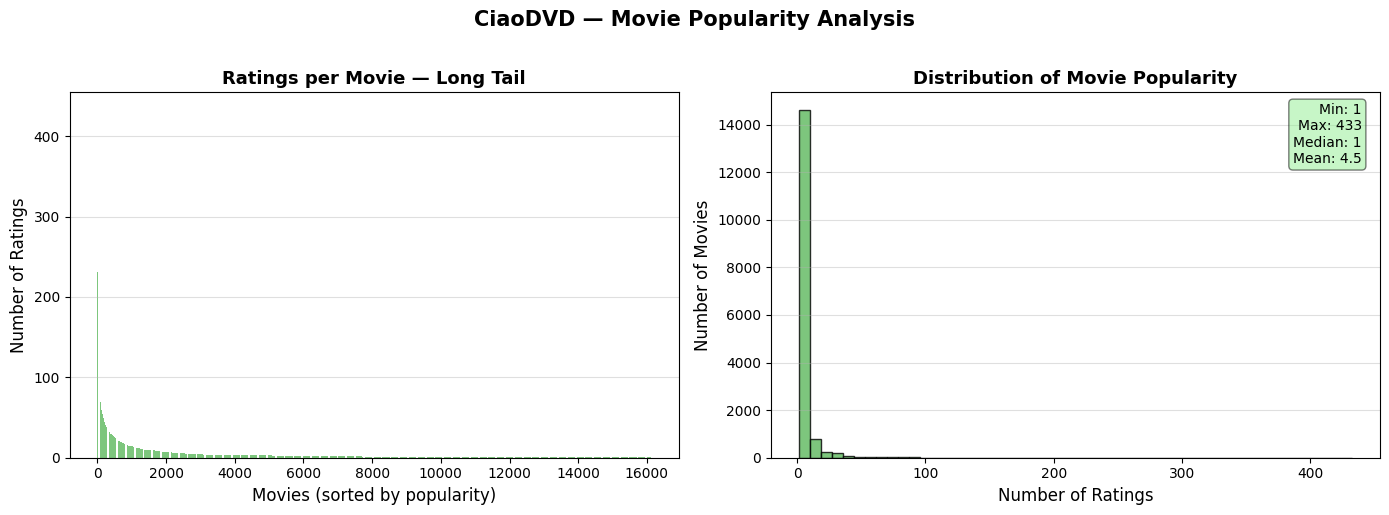

✅ Saved ratings_per_movie.png


In [9]:
# Cell 8: Ratings per movie — long tail distribution
ratings_per_movie = df.groupby("movieId")["rating"].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sorted bar
axes[0].bar(range(len(ratings_per_movie)), ratings_per_movie.values,
            color="#5cb85c", alpha=0.8)
axes[0].set_xlabel("Movies (sorted by popularity)", fontsize=12)
axes[0].set_ylabel("Number of Ratings", fontsize=12)
axes[0].set_title("Ratings per Movie — Long Tail", fontsize=13, fontweight="bold")
axes[0].grid(axis="y", alpha=0.4)

# Right: histogram
axes[1].hist(ratings_per_movie.values, bins=50, color="#5cb85c",
             edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Number of Ratings", fontsize=12)
axes[1].set_ylabel("Number of Movies", fontsize=12)
axes[1].set_title("Distribution of Movie Popularity", fontsize=13, fontweight="bold")
axes[1].grid(axis="y", alpha=0.4)

stats_text = (f"Min: {ratings_per_movie.min()}\n"
              f"Max: {ratings_per_movie.max()}\n"
              f"Median: {ratings_per_movie.median():.0f}\n"
              f"Mean: {ratings_per_movie.mean():.1f}")
axes[1].text(0.97, 0.97, stats_text, transform=axes[1].transAxes,
             va="top", ha="right", fontsize=10,
             bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.5))

plt.suptitle("CiaoDVD — Movie Popularity Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/figures/ratings_per_movie.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved ratings_per_movie.png")

In [10]:
# Cell 9: EDA Summary
print("=" * 50)
print("         EDA SUMMARY — CiaoDVD Dataset")
print("=" * 50)
print(f"  Total ratings         : {n_ratings:,}")
print(f"  Unique users          : {n_users:,}")
print(f"  Unique movies         : {n_movies:,}")
print(f"  Matrix sparsity       : {sparsity:.4%}")
print(f"  Most active user      : {ratings_per_user.max()} ratings")
print(f"  Most rated movie      : {ratings_per_movie.max()} ratings")
print(f"  % users with < 5 ratings : "
      f"{(ratings_per_user < 5).sum() / n_users:.1%}")
print(f"  % movies with < 5 ratings: "
      f"{(ratings_per_movie < 5).sum() / n_movies:.1%}")
print("=" * 50)
print("\n✅ EDA complete. Figures saved to results/figures/")

         EDA SUMMARY — CiaoDVD Dataset
  Total ratings         : 72,665
  Unique users          : 17,615
  Unique movies         : 16,121
  Matrix sparsity       : 99.9744%
  Most active user      : 1106 ratings
  Most rated movie      : 433 ratings
  % users with < 5 ratings : 85.1%
  % movies with < 5 ratings: 80.9%

✅ EDA complete. Figures saved to results/figures/
